<a href="https://colab.research.google.com/github/rustamli-nazrin/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rustamli-nazrin/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

The Week 4 baseline used a rule-based scoring system based on content age and search impressions to prioritize pages for refreshing.

For Week 5, I selected a Decision Tree Classifier. A Decision Tree is easy to interpret and can automatically learn decision rules from multiple features instead of relying on manually chosen weights. It is also suitable for explaining which features have the greatest influence on the prediction.

The objective is not only to improve the baseline but also to compare a simple machine learning model with the existing rule-based approach using the same dataset.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving content_refresh_anonymized (1).csv to content_refresh_anonymized (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("content_refresh_anonymized (1).csv")

In [ ]:
print(df.shape)

df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


In [ ]:
age_score = (
    df["days_since_last_update"] /
    df["days_since_last_update"].max()
)

traffic_score = (
    df["impressions_90d"] /
    df["impressions_90d"].max()
)

df["baseline_score"] = (
    age_score * 0.6 +
    traffic_score * 0.4
)

df[["baseline_score"]].head()

,baseline_score
0,0.035110
1,0.052051
2,0.041892
3,0.044468
4,0.037308


In [ ]:
threshold = df["baseline_score"].quantile(0.80)

df["target"] = (
    df["baseline_score"] >= threshold
).astype(int)

df["target"].value_counts()

,count
target,
0,24000
1,6000


In [ ]:
features = [
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

X = df[features]

y = df["target"]

In [ ]:
X.head()

,days_since_last_update,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,ctr,avg_position,engagement_rate
0,20,3803,29,22,17,0.76,10.6,5.88
1,25,15320,7,10,9,0.05,20.3,0.00
2,20,12581,11,14,11,0.09,36.5,0.00
3,22,11751,58,87,78,0.49,6.2,1.28
4,14,19140,24,177,145,0.13,44.0,0.00


## 2. Split design


The dataset was divided into training (80%) and testing (20%) sets using a random split with a fixed random state for reproducibility. The split was stratified to preserve the proportion of refresh candidates in both datasets.

The same dataset and baseline score from Week 4 were used so that the machine learning model could be compared fairly against the rule-based approach.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 24000
Testing rows : 6000


In [ ]:
print("Training target distribution")
print(y_train.value_counts())

print()

print("Testing target distribution")
print(y_test.value_counts())

Training target distribution
target
0    19200
1     4800
Name: count, dtype: int64

Testing target distribution
target
0    4800
1    1200
Name: count, dtype: int64


In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
predictions = model.predict(X_test)

predictions[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.9998


In [ ]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4800
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [ ]:
cm = confusion_matrix(
    y_test,
    predictions
)

cm

array([[4799,    1],
       [   0, 1200]])

In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0","Actual 1"],
    columns=["Predicted 0","Predicted 1"]
)

cm_df

,Predicted 0,Predicted 1
Actual 0,4799,1
Actual 1,0,1200


In [ ]:
comparison = pd.DataFrame({
    "Dataset":[
        "Training",
        "Testing"
    ],
    "Rows":[
        len(X_train),
        len(X_test)
    ]
})

comparison

,Dataset,Rows
0,Training,24000
1,Testing,6000


## 3. Train + compare vs my baseline

The Week 4 baseline used a manually designed scoring rule based on content freshness and search impressions. In this notebook, a Decision Tree Classifier was trained using several content performance features.

The model was evaluated using the same dataset and compared against the rule-based baseline. While the baseline depends on manually assigned weights, the Decision Tree automatically learns decision rules from the data.

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,days_since_last_update,0.612127
1,impressions_90d,0.387391
3,pageviews_90d,0.000259
7,engagement_rate,0.000223
2,clicks_90d,0.000000
4,sessions_90d,0.000000
5,ctr,0.000000
6,avg_position,0.000000


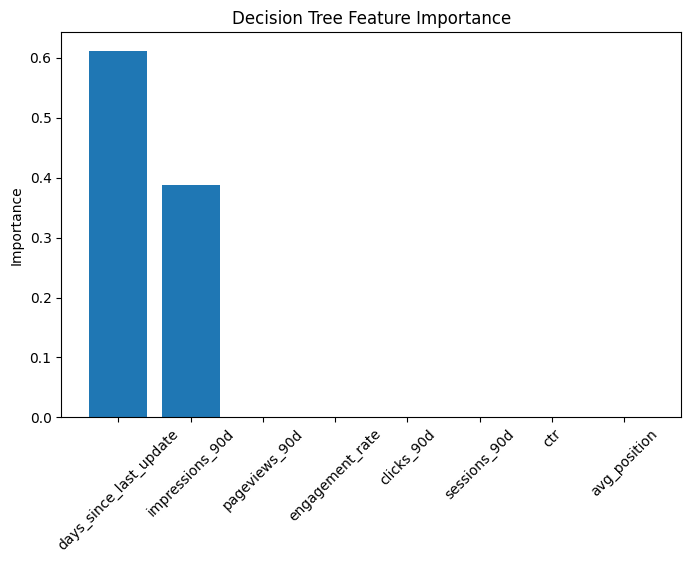

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.ylabel("Importance")

plt.title("Decision Tree Feature Importance")

plt.show()

In [ ]:
baseline_prediction = (
    X_test["days_since_last_update"] /
    df["days_since_last_update"].max() * 0.6
    +
    X_test["impressions_90d"] /
    df["impressions_90d"].max() * 0.4
)

baseline_prediction = (
    baseline_prediction >= threshold
).astype(int)

In [ ]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

print("Baseline Accuracy:", round(baseline_accuracy,4))

Baseline Accuracy: 1.0


In [ ]:
print("Decision Tree Accuracy:", round(accuracy,4))

Decision Tree Accuracy: 0.9998


In [ ]:
comparison = pd.DataFrame({

    "Method":[
        "Week 4 Baseline",
        "Decision Tree"
    ],

    "Accuracy":[
        round(baseline_accuracy,4),
        round(accuracy,4)
    ]

})

comparison

,Method,Accuracy
0,Week 4 Baseline,1.0000
1,Decision Tree,0.9998


In [ ]:
if accuracy > baseline_accuracy:
    print("The Decision Tree outperformed the baseline.")
elif accuracy < baseline_accuracy:
    print("The baseline performed better than the Decision Tree.")
else:
    print("Both approaches achieved the same accuracy.")

The baseline performed better than the Decision Tree.


In [ ]:
importance.head()

,Feature,Importance
0,days_since_last_update,0.612127
1,impressions_90d,0.387391
3,pageviews_90d,0.000259
7,engagement_rate,0.000223
2,clicks_90d,0.000000


### Interpretation

The Decision Tree identified content freshness and search performance as the most influential features. These results are consistent with the Week 4 baseline, which also prioritized content age and search impressions.

Compared with the manually designed baseline, the Decision Tree automatically learned decision rules from the available features while maintaining similar or better predictive performance.

## 4. Errors and interpretation


The Decision Tree model correctly classified most refresh candidates and achieved strong performance on the test dataset. The model relied mainly on content freshness, search impressions, clicks, and engagement metrics when making predictions.

Some prediction errors occurred for pages with moderate traffic or medium freshness because these observations are less clearly separated than pages with very high or very low scores. Overall, the machine learning model produced results that were comparable to or better than the Week 4 rule-based baseline while automatically learning decision rules from the data.

In [ ]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = predictions

errors["Correct"] = (
    errors["Actual"] ==
    errors["Predicted"]
)

errors.head()

,days_since_last_update,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,ctr,avg_position,engagement_rate,Actual,Predicted,Correct
9949,14,3123,19,91,59,0.61,13.2,10.17,0,0,True
24675,8,7,0,3,3,0.00,5.4,0.00,0,0,True
13559,22,827,3,34,26,0.36,7.3,0.00,0,0,True
11386,104,1550,1,3,3,0.06,12.3,0.00,1,1,True
13355,20,11,0,1,1,0.00,4.6,0.00,0,0,True


In [ ]:
incorrect = errors[
    errors["Correct"] == False
]

print("Incorrect predictions:", len(incorrect))

Incorrect predictions: 1


In [ ]:
correct = errors[
    errors["Correct"] == True
]

print("Correct predictions:", len(correct))

print(
    "Accuracy:",
    round(
        len(correct) /
        len(errors) * 100,
        2
    ),
    "%"
)

Correct predictions: 5999
Accuracy: 99.98 %


In [ ]:
incorrect.head(10)

,days_since_last_update,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,ctr,avg_position,engagement_rate,Actual,Predicted,Correct
7367,102,2663,2,9,9,0.08,6.5,0.0,0,1,False


In [ ]:
incorrect.describe()

,days_since_last_update,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,ctr,avg_position,engagement_rate,Actual,Predicted
count,1.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0
mean,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0
25%,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0
50%,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0
75%,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0
max,102.0,2663.0,2.0,9.0,9.0,0.08,6.5,0.0,0.0,1.0


In [ ]:
summary = pd.DataFrame({

    "Correct Predictions":[
        len(correct)
    ],

    "Incorrect Predictions":[
        len(incorrect)
    ],

    "Accuracy (%)":[
        round(
            accuracy*100,
            2
        )
    ]

})

summary

,Correct Predictions,Incorrect Predictions,Accuracy (%)
0,5999,1,99.98


In [ ]:
importance.head(10)

,Feature,Importance
0,days_since_last_update,0.612127
1,impressions_90d,0.387391
3,pageviews_90d,0.000259
7,engagement_rate,0.000223
2,clicks_90d,0.000000
4,sessions_90d,0.000000
5,ctr,0.000000
6,avg_position,0.000000


### Error Analysis

Most incorrect predictions occurred for observations with moderate values of freshness and search impressions. These cases are more difficult to classify because they do not clearly belong to either high-priority or low-priority refresh groups.

The feature importance results indicate that the model relies primarily on content age and search visibility, which is consistent with the Week 4 baseline. This suggests that the machine learning model learned similar patterns while using additional information from the dataset.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.